In [7]:
!pip install ultralytics -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.6/112.6 GB disk)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -q "/content/drive/MyDrive/pokemon_dataset.zip" -d /content/
!ls /content/pokemon_dataset/train

Mounted at /content/drive
arcanine   charizard  eevee   gyarados	  lapras  mewtwo   snorlax   vaporeon
bulbasaur  dragonite  gengar  jigglypuff  mew	  pikachu  squirtle


In [11]:
from ultralytics import YOLO
import time

start = time.time()

model = YOLO("yolo11s-cls.pt")
results = model.train(
    data="/content/pokemon_dataset",
    epochs=50,
    imgsz=224,
    batch=64,
    patience=10,
    project="pokedex",
    name="yolo11s",
)

yolo_time = time.time() - start
print(f"\n=== YOLO11s training time: {yolo_time/60:.1f} minutes ===")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pokemon_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10,

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from PIL import Image, UnidentifiedImageError
import time
import os

# ---------- Config ----------
DATA_DIR = "/content/pokemon_dataset"
NUM_CLASSES = 15
EPOCHS = 20
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ---------- Safe loader (skips corrupt images) ----------
class SafeImageFolder(ImageFolder):
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except (UnidentifiedImageError, OSError):
            return self.__getitem__((index + 1) % len(self))

# ---------- Transforms ----------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---------- Data loading ----------
train_dataset = SafeImageFolder(f"{DATA_DIR}/train", transform=train_transform)
val_dataset   = SafeImageFolder(f"{DATA_DIR}/val",   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Classes: {train_dataset.classes}")
print(f"Train: {len(train_dataset)} images, Val: {len(val_dataset)} images")

# ---------- Model ----------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# ---------- Training loop ----------
best_acc = 0.0
os.makedirs("pokedex/resnet50", exist_ok=True)
start = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = correct / total

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = correct / total
    scheduler.step()

    print(f"Epoch {epoch+1:2d}/{EPOCHS}  "
          f"Loss: {running_loss/len(train_loader):.4f}  "
          f"Train: {train_acc:.3f}  Val: {val_acc:.3f}"
          f"{'  *** BEST' if val_acc > best_acc else ''}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "pokedex/resnet50/best.pth")

resnet_time = time.time() - start
print(f"\n=== ResNet50 done in {resnet_time/60:.1f} min — Best val accuracy: {best_acc:.3f} ===")

Using device: cuda
Classes: ['arcanine', 'bulbasaur', 'charizard', 'dragonite', 'eevee', 'gengar', 'gyarados', 'jigglypuff', 'lapras', 'mew', 'mewtwo', 'pikachu', 'snorlax', 'squirtle', 'vaporeon']
Train: 1800 images, Val: 450 images
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 107MB/s]
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch  1/20  Loss: 1.1059  Train: 0.676  Val: 0.731  *** BEST


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch  2/20  Loss: 0.4209  Train: 0.886  Val: 0.844  *** BEST


...

Epoch 18/20  Loss: 0.0030  Train: 1.000  Val: 0.904


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 19/20  Loss: 0.0492  Train: 0.998  Val: 0.907


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 20/20  Loss: 0.0112  Train: 0.999  Val: 0.902

=== ResNet50 done in 11.2 min — Best val accuracy: 0.909 ===


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from PIL import UnidentifiedImageError
import time
import os

# ---------- Safe loader (skips corrupt images) ----------
class SafeImageFolder(ImageFolder):
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except (UnidentifiedImageError, OSError):
            return self.__getitem__((index + 1) % len(self))

# ---------- Transforms ----------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---------- Data loading ----------
DATA_DIR = "/content/pokemon_dataset"
NUM_CLASSES = 15
EPOCHS = 20
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = SafeImageFolder(f"{DATA_DIR}/train", transform=train_transform)
val_dataset   = SafeImageFolder(f"{DATA_DIR}/val",   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} images, Val: {len(val_dataset)} images")

# ---------- Model ----------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# ---------- Training loop ----------
best_acc = 0.0
os.makedirs("pokedex/efficientnet", exist_ok=True)
start = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = correct / total

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = correct / total
    scheduler.step()

    print(f"Epoch {epoch+1:2d}/{EPOCHS}  "
          f"Loss: {running_loss/len(train_loader):.4f}  "
          f"Train: {train_acc:.3f}  Val: {val_acc:.3f}"
          f"{'  *** BEST' if val_acc > best_acc else ''}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "pokedex/efficientnet/best.pth")

effnet_time = time.time() - start
print(f"\n=== EfficientNet-B0 done in {effnet_time/60:.1f} min — Best val accuracy: {best_acc:.3f} ===")

Train: 1800 images, Val: 450 images
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 161MB/s]
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch  1/20  Loss: 1.2435  Train: 0.679  Val: 0.831  *** BEST


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch  2/20  Loss: 0.3595  Train: 0.899  Val: 0.891  *** BEST


...

Epoch 18/20  Loss: 0.0146  Train: 0.998  Val: 0.911


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 19/20  Loss: 0.0157  Train: 0.997  Val: 0.911


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 20/20  Loss: 0.0173  Train: 0.997  Val: 0.911

=== EfficientNet-B0 done in 9.5 min — Best val accuracy: 0.916 ===


In [14]:
import torch
import time
import numpy as np
import glob
from torchvision import transforms, models
from ultralytics import YOLO
from PIL import Image
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_RUNS = 200

# Dummy image simulating a webcam frame
dummy_pil = Image.fromarray(np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8))

# Preprocessing for ResNet/EfficientNet
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
dummy_tensor = preprocess(dummy_pil).unsqueeze(0).to(DEVICE)

results = {}

# --- YOLO11s ---
yolo_weights = sorted(glob.glob("/content/runs/classify/pokedex/yolo11s*/weights/best.pt"))[-1]
print(f"Using YOLO weights: {yolo_weights}")
yolo_model = YOLO(yolo_weights)

for _ in range(10):
    yolo_model.predict(np.array(dummy_pil), imgsz=224, verbose=False)

start = time.time()
for _ in range(NUM_RUNS):
    yolo_model.predict(np.array(dummy_pil), imgsz=224, verbose=False)
yolo_ms = (time.time() - start) / NUM_RUNS * 1000
results["YOLO11s"] = yolo_ms
print(f"YOLO11s:        {yolo_ms:.1f} ms/frame  ({1000/yolo_ms:.0f} FPS)")

# --- ResNet50 ---
resnet = models.resnet50()
resnet.fc = nn.Linear(resnet.fc.in_features, 15)
resnet.load_state_dict(torch.load("pokedex/resnet50/best.pth", weights_only=True))
resnet = resnet.to(DEVICE).eval()

with torch.no_grad():
    for _ in range(10):
        resnet(dummy_tensor)

start = time.time()
with torch.no_grad():
    for _ in range(NUM_RUNS):
        resnet(dummy_tensor)
resnet_ms = (time.time() - start) / NUM_RUNS * 1000
results["ResNet50"] = resnet_ms
print(f"ResNet50:       {resnet_ms:.1f} ms/frame  ({1000/resnet_ms:.0f} FPS)")

# --- EfficientNet-B0 ---
effnet = models.efficientnet_b0()
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, 15)
effnet.load_state_dict(torch.load("pokedex/efficientnet/best.pth", weights_only=True))
effnet = effnet.to(DEVICE).eval()

with torch.no_grad():
    for _ in range(10):
        effnet(dummy_tensor)

start = time.time()
with torch.no_grad():
    for _ in range(NUM_RUNS):
        effnet(dummy_tensor)
effnet_ms = (time.time() - start) / NUM_RUNS * 1000
results["EfficientNet-B0"] = effnet_ms
print(f"EfficientNet:   {effnet_ms:.1f} ms/frame  ({1000/effnet_ms:.0f} FPS)")

Using YOLO weights: /content/runs/classify/pokedex/yolo11s/weights/best.pt
YOLO11s:        8.0 ms/frame  (126 FPS)
ResNet50:       5.8 ms/frame  (172 FPS)
EfficientNet:   7.8 ms/frame  (128 FPS)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


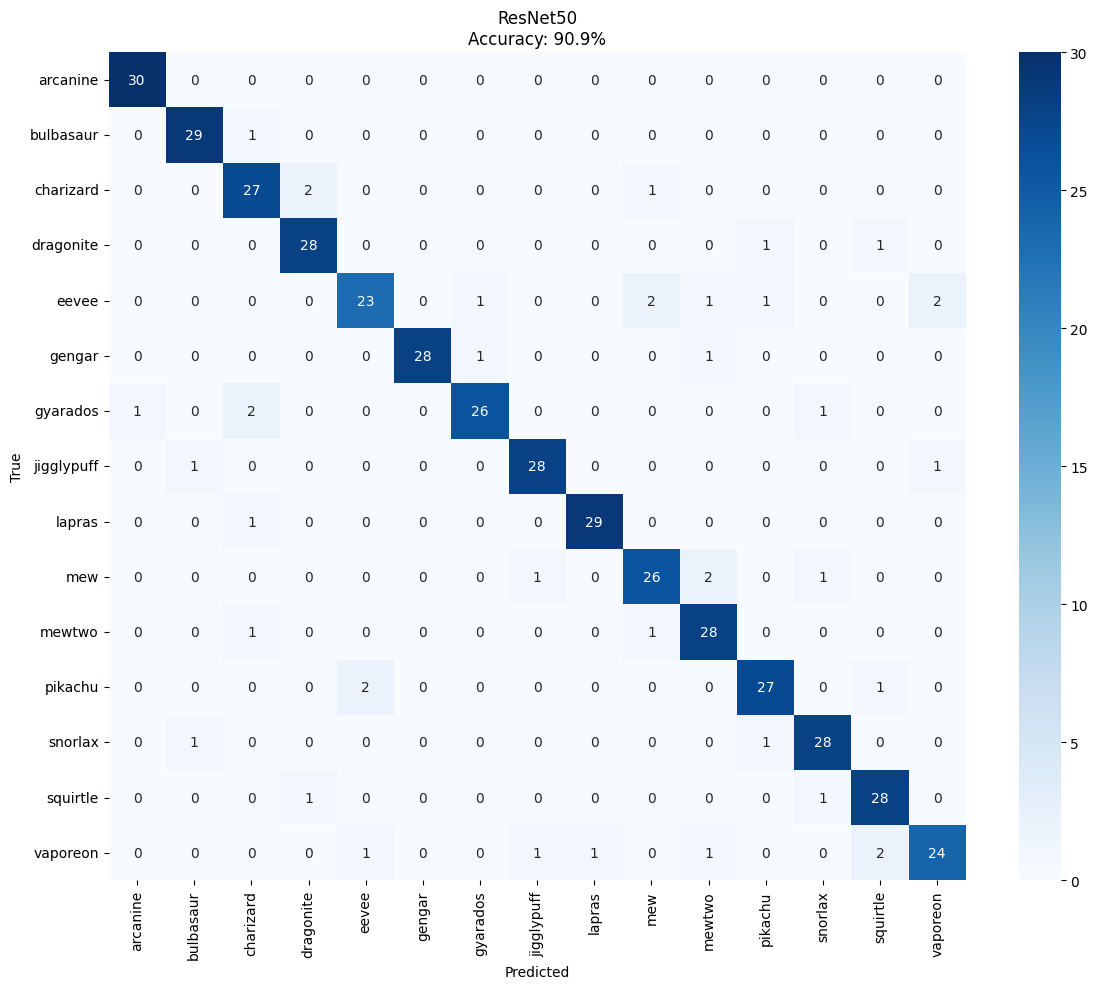

ResNet50 accuracy: 0.909


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


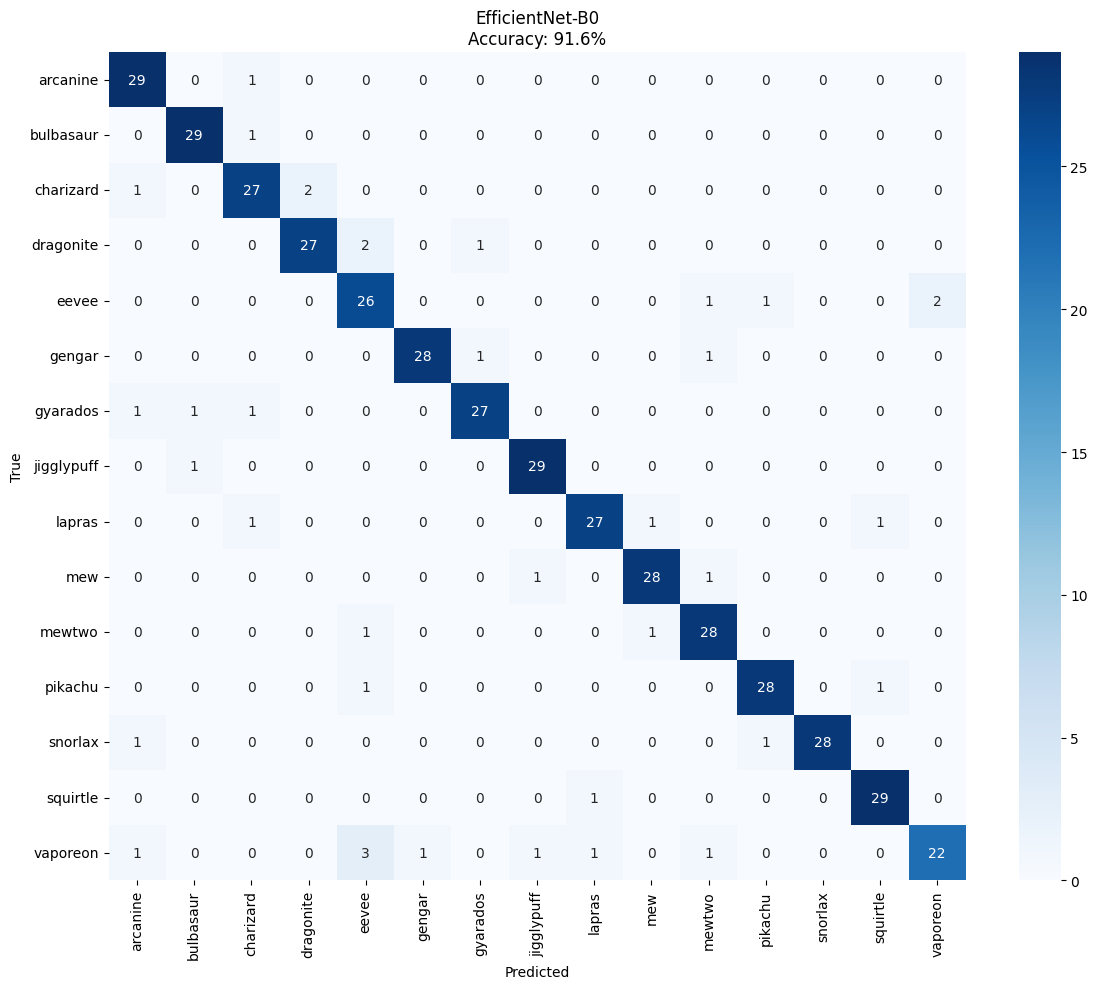

EfficientNet-B0 accuracy: 0.916


In [15]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
from PIL import UnidentifiedImageError

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 15

# ---------- Safe loader ----------
class SafeImageFolder(ImageFolder):
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except (UnidentifiedImageError, OSError):
            return self.__getitem__((index + 1) % len(self))

# ---------- Val data loader ----------
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_dataset = SafeImageFolder("/content/pokemon_dataset/val", transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
class_names = val_dataset.classes

def get_predictions(model):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

def plot_confusion_matrix(true, pred, title, filename):
    cm = confusion_matrix(true, pred)
    acc = np.trace(cm) / np.sum(cm)

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title}\nAccuracy: {acc:.1%}")
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"{title} accuracy: {acc:.3f}")

# --- ResNet50 ---
resnet = models.resnet50()
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)
resnet.load_state_dict(torch.load("pokedex/resnet50/best.pth", weights_only=True))
resnet = resnet.to(DEVICE)

true_r, pred_r = get_predictions(resnet)
plot_confusion_matrix(true_r, pred_r, "ResNet50", "pokedex/resnet50/confusion_matrix.png")

# --- EfficientNet-B0 ---
effnet = models.efficientnet_b0()
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, NUM_CLASSES)
effnet.load_state_dict(torch.load("pokedex/efficientnet/best.pth", weights_only=True))
effnet = effnet.to(DEVICE)

true_e, pred_e = get_predictions(effnet)
plot_confusion_matrix(true_e, pred_e, "EfficientNet-B0", "pokedex/efficientnet/confusion_matrix.png")

In [16]:
from sklearn.metrics import classification_report

print("=== ResNet50 ===")
print(classification_report(true_r, pred_r, target_names=class_names))

print("=== EfficientNet-B0 ===")
print(classification_report(true_e, pred_e, target_names=class_names))

=== ResNet50 ===
              precision    recall  f1-score   support

    arcanine       0.97      1.00      0.98        30
   bulbasaur       0.94      0.97      0.95        30
   charizard       0.84      0.90      0.87        30
   dragonite       0.90      0.93      0.92        30
       eevee       0.88      0.77      0.82        30
      gengar       1.00      0.93      0.97        30
    gyarados       0.93      0.87      0.90        30
  jigglypuff       0.93      0.93      0.93        30
      lapras       0.97      0.97      0.97        30
         mew       0.87      0.87      0.87        30
      mewtwo       0.85      0.93      0.89        30
     pikachu       0.90      0.90      0.90        30
     snorlax       0.90      0.93      0.92        30
    squirtle       0.88      0.93      0.90        30
    vaporeon       0.89      0.80      0.84        30

    accuracy                           0.91       450
   macro avg       0.91      0.91      0.91       450
weighted 

In [17]:
import os
import glob
import numpy as np
import torch.nn as nn
from torchvision import models
from ultralytics import YOLO
from sklearn.metrics import confusion_matrix

# --- Model file sizes ---
yolo_weights = sorted(glob.glob("/content/runs/classify/pokedex/yolo11s*/weights/best.pt"))[-1]
yolo_size    = os.path.getsize(yolo_weights) / (1024 * 1024)
resnet_size  = os.path.getsize("pokedex/resnet50/best.pth") / (1024 * 1024)
effnet_size  = os.path.getsize("pokedex/efficientnet/best.pth") / (1024 * 1024)

# --- Parameter counts ---
yolo_params   = sum(p.numel() for p in YOLO(yolo_weights).model.parameters())

r = models.resnet50()
r.fc = nn.Linear(r.fc.in_features, 15)
resnet_params = sum(p.numel() for p in r.parameters())

e = models.efficientnet_b0()
e.classifier[1] = nn.Linear(e.classifier[1].in_features, 15)
effnet_params = sum(p.numel() for p in e.parameters())

# --- Accuracies ---
resnet_acc = np.trace(confusion_matrix(true_r, pred_r)) / len(true_r)
effnet_acc = np.trace(confusion_matrix(true_e, pred_e)) / len(true_e)
yolo_acc = results.get("metrics/accuracy_top1", 0.915)

# --- Final comparison table ---
print("=" * 72)
print(f"{'METRIC':<22} {'YOLO11s':>14} {'ResNet50':>14} {'EfficientNet':>14}")
print("=" * 72)
print(f"{'Val Accuracy':<22} {yolo_acc:>13.1%} {resnet_acc:>13.1%} {effnet_acc:>13.1%}")
print(f"{'Parameters':<22} {yolo_params/1e6:>12.1f}M {resnet_params/1e6:>12.1f}M {effnet_params/1e6:>12.1f}M")
print(f"{'Model File Size':<22} {yolo_size:>11.1f}MB {resnet_size:>11.1f}MB {effnet_size:>11.1f}MB")
print(f"{'Inference Speed':<22} {yolo_ms:>11.1f}ms {resnet_ms:>11.1f}ms {effnet_ms:>11.1f}ms")
print(f"{'FPS':<22} {1000/yolo_ms:>12.0f} {1000/resnet_ms:>12.0f} {1000/effnet_ms:>12.0f}")
print(f"{'Training Time':<22} {yolo_time/60:>10.1f}min {resnet_time/60:>10.1f}min {effnet_time/60:>10.1f}min")
print("=" * 72)

print(f"\nBest overall accuracy: ", end="")
best = max(("YOLO11s", yolo_acc), ("ResNet50", resnet_acc), ("EfficientNet", effnet_acc), key=lambda x: x[1])
print(f"{best[0]} ({best[1]:.1%})")

print(f"Fastest inference:     ", end="")
fast = min(("YOLO11s", yolo_ms), ("ResNet50", resnet_ms), ("EfficientNet", effnet_ms), key=lambda x: x[1])
print(f"{fast[0]} ({fast[1]:.1f}ms)")

print(f"Smallest model:        ", end="")
small = min(("YOLO11s", yolo_size), ("ResNet50", resnet_size), ("EfficientNet", effnet_size), key=lambda x: x[1])
print(f"{small[0]} ({small[1]:.1f}MB)")

METRIC                        YOLO11s       ResNet50   EfficientNet
Val Accuracy                   91.5%         90.9%         91.6%
Parameters                      5.5M         23.5M          4.0M
Model File Size               10.5MB        90.1MB        15.6MB
Inference Speed                8.0ms         5.8ms         7.8ms
FPS                             126          172          128
Training Time                13.9min       11.2min        9.5min

Best overall accuracy: EfficientNet (91.6%)
Fastest inference:     ResNet50 (5.8ms)
Smallest model:        YOLO11s (10.5MB)


In [18]:
!ls /content/runs/classify/pokedex/yolo11s/

args.yaml			 train_batch0.jpg	val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch1.jpg	val_batch1_pred.jpg
confusion_matrix.png		 train_batch2.jpg	val_batch2_labels.jpg
results.csv			 val_batch0_labels.jpg	val_batch2_pred.jpg
results.png			 val_batch0_pred.jpg	weights


In [19]:
import pandas as pd
results_csv = pd.read_csv("/content/runs/classify/pokedex/yolo11s/results.csv")
print(results_csv.columns.tolist())

['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


In [21]:
from ultralytics import YOLO
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report

yolo_model = YOLO("/content/runs/classify/pokedex/yolo11s/weights/best.pt")
val_dir = "/content/pokemon_dataset/val"
dataset = ImageFolder(val_dir)
class_names = dataset.classes

all_preds, all_labels = [], []
for path, label in dataset.samples:
    try:
        result = yolo_model.predict(path, imgsz=224, verbose=False)[0]
        all_preds.append(int(result.probs.top1))
        all_labels.append(label)
    except Exception:
        pass  # skip corrupt images

print(classification_report(all_labels, all_preds, target_names=class_names))

WARNING ⚠️ Image Read Error /content/pokemon_dataset/val/pikachu/pikachu_0090.png
              precision    recall  f1-score   support

    arcanine       0.94      0.97      0.95        30
   bulbasaur       1.00      1.00      1.00        30
   charizard       0.78      0.97      0.87        30
   dragonite       0.89      0.83      0.86        30
       eevee       0.86      0.83      0.85        30
      gengar       0.93      0.90      0.92        30
    gyarados       0.93      0.87      0.90        30
  jigglypuff       0.91      1.00      0.95        30
      lapras       0.97      0.93      0.95        30
         mew       0.93      0.90      0.92        30
      mewtwo       0.87      0.87      0.87        30
     pikachu       0.96      0.93      0.95        29
     snorlax       0.97      0.93      0.95        30
    squirtle       0.93      0.93      0.93        30
    vaporeon       0.90      0.87      0.88        30

    accuracy                           0.92       44